<a href="https://colab.research.google.com/github/OsvaEscamilla22/ms-data-science-sentiment-analysis-amazon-reviews/blob/main/notebooks/sentiment_analysis_amazon_reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ACTIVIDAD 3-PROYECTO INTEGRADOR PARTE 1**
Equipo 8

Contenido:
1. Cargar Librerias
2. Leer archivo y procesar datos
3. Machine Learning Models
4. Metricas
5. Visualizaciones de las Metricas para evaluar mejor modelo

In [1]:
#Cargar Librerias

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier # Added this import
from sklearn.metrics import classification_report,accuracy_score

In [5]:
# ===============================
# 2.1 CARGAR Y LEER ARCHIVO AMAZON
# ===============================

from pathlib import Path
import pandas as pd

# Ruta principal esperada dentro del repositorio
file_path = Path("/content/data/Amazon_Unlocked_Mobile.csv")

# Validación de existencia
if not file_path.exists():
    raise FileNotFoundError(
        "Dataset not found. Please place 'Amazon_Unlocked_Mobile.csv' inside the data/ folder."
    )

# Lectura del dataset
# Se usa engine='python' para manejar errores de parseo como 'EOF inside string'.
# Esto es más flexible con archivos CSV que tienen formatos irregulares.
# Se añade on_bad_lines='warn' para manejar líneas con formato incorrecto sin detener la ejecución.
df = pd.read_csv(file_path, engine='python', on_bad_lines='warn')

# Vista previa
display(df.head())

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5.0,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4.0,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5.0,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4.0,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4.0,Great phone to replace my lost phone. The only...,0.0


2.1 CARGAR Y LEER ARCHIVO **AMAZON**

In [6]:
# Contar el total de valores nulos en el DataFrame
total_nulls = df.isnull().sum().sum()
print(f"Total de valores nulos detectados en el DataFrame: {total_nulls}")

# Obtener el recuento de valores nulos por columna y mostrarlos en una tabla
null_counts_per_column = df.isnull().sum()
print("\nValores nulos por columna:")
display(pd.DataFrame(null_counts_per_column, columns=['Cantidad de Nulos']))

Total de valores nulos detectados en el DataFrame: 55256

Valores nulos por columna:


,Cantidad de Nulos
Product Name,0
Brand Name,43438
Price,3051
Rating,1
Reviews,42
Review Votes,8724


**2.2 PRE PROCESAMIENTO DE LOS DATOS**

In [7]:
# ===============================
# 2.2 DATA PREPROCESSING
# ===============================

# Remove rows with missing values
df = df.dropna().copy()

# Use the first 50,000 records to keep the academic example lightweight
df = df.iloc[:50000, :].copy()

# Create sentiment labels from rating
# Positive: rating >= 4
# Negative: rating <= 2
# Neutral: rating == 3

df["Positively Rated"] = (df["Rating"] >= 4).astype(int)
df["Poorly Rated"] = (df["Rating"] < 3).astype(int)
df["Neutral Rated"] = (df["Rating"] == 3).astype(int)

# Keep only relevant columns for modeling
misDatos = df[["Reviews", "Rating", "Positively Rated", "Poorly Rated", "Neutral Rated"]]

print(misDatos.head(20))

# Final modeling dataset
misDatos = misDatos[["Reviews", "Positively Rated", "Poorly Rated", "Neutral Rated"]]

print(misDatos.head(20))

                                              Reviews  Rating  \
0   I feel so LUCKY to have found this used (phone...     5.0   
1   nice phone, nice up grade from my pantach revu...     4.0   
2                                        Very pleased     5.0   
3   It works good but it goes slow sometimes but i...     4.0   
4   Great phone to replace my lost phone. The only...     4.0   
5   I already had a phone with problems... I know ...     1.0   
6   The charging port was loose. I got that solder...     2.0   
7   Phone looks good but wouldn't stay charged, ha...     2.0   
8   I originally was using the Samsung S2 Galaxy f...     5.0   
9   It's battery life is great. It's very responsi...     3.0   
10  My fiance had this phone previously, but cause...     3.0   
11  This is a great product it came after two days...     5.0   
12  These guys are the best! I had a little situat...     5.0   
13  I'm really disappointed about my phone and ser...     1.0   
14  Ordered this phone as

**2.3 Data Split**

In [8]:
# ===============================
# 2.3 TRAIN-TEST SPLIT
# ===============================

from sklearn.model_selection import train_test_split

train_size = 0.75
test_size = 1 - train_size

# Split data into training and testing sets
trainSet, testSet = train_test_split(
    misDatos,
    test_size=test_size,
    random_state=0
)

print(f"Train set shape: {trainSet.shape}")
print(f"Test set shape: {testSet.shape}")

display(trainSet.head())
display(testSet.head())

Train set shape: (37500, 4)
Test set shape: (12500, 4)


,Reviews,Positively Rated,Poorly Rated,Neutral Rated
49657,Super,1,0,0
25773,Awesome service and went out of way to make su...,1,0,0
42791,"The phone is as described, no complaints. Its ...",1,0,0
44626,"Very undone. Speaker was blown, front facing h...",0,1,0
39543,"The phone seems to be decent, but I can't be s...",0,1,0


,Reviews,Positively Rated,Poorly Rated,Neutral Rated
18699,Great purchase had a bit of problem getting Fa...,1,0,0
27243,Very fast shipping. Product like description,1,0,0
62620,I was very excited to receive this in the mail...,0,0,1
33496,"It stoped working a week atfer i got it , it s...",0,1,0
57107,not good,0,1,0


**2.4 Vectorizar Datos**

In [9]:
# ===============================
# 2.4 TF-IDF VECTORIZATION
# ===============================

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    min_df=5,
    max_df=0.8,
    sublinear_tf=True,
    use_idf=True
)

train_vectors = vectorizer.fit_transform(trainSet["Reviews"])
test_vectors = vectorizer.transform(testSet["Reviews"])

print(f"Train vectors shape: {train_vectors.shape}")
print(f"Test vectors shape: {test_vectors.shape}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")

Train vectors shape: (37500, 4871)
Test vectors shape: (12500, 4871)
Vocabulary size: 4871


**3. ML Model**

**CLASIFICADOR 1: DECISION TREE**

In [10]:
# ===============================
# 3.1 DECISION TREE MODEL
# ===============================

from sklearn.tree import DecisionTreeClassifier
import pandas as pd

target_columns = ["Positively Rated", "Poorly Rated", "Neutral Rated"]

# Train Decision Tree model
classifier_dt = DecisionTreeClassifier(max_depth=5, random_state=0)
classifier_dt.fit(train_vectors, trainSet[target_columns])

# Generate predictions
prediction_dt = classifier_dt.predict(test_vectors)

# Store predictions in a DataFrame
df_dt = pd.DataFrame(
    prediction_dt,
    columns=target_columns,
    index=testSet.index
)

print("Decision Tree predictions:")
display(df_dt.head())

print("Ground truth:")
display(testSet[target_columns].head())

Decision Tree predictions:


,Positively Rated,Poorly Rated,Neutral Rated
18699,1,0,0
27243,1,0,0
62620,0,0,1
33496,1,0,0
57107,1,0,0


Ground truth:


,Positively Rated,Poorly Rated,Neutral Rated
18699,1,0,0
27243,1,0,0
62620,0,0,1
33496,0,1,0
57107,0,1,0


**CLASIFICADOR 2: RANDOM FOREST**

In [11]:
# ===============================
# 3.2 RANDOM FOREST MODEL
# ===============================

from sklearn.ensemble import RandomForestClassifier
import pandas as pd

target_columns = ["Positively Rated", "Poorly Rated", "Neutral Rated"]

# Train Random Forest model
classifier_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=0
)
classifier_rf.fit(train_vectors, trainSet[target_columns])

# Generate predictions
prediction_rf = classifier_rf.predict(test_vectors)

# Store predictions in a DataFrame
df_rf = pd.DataFrame(
    prediction_rf,
    columns=target_columns,
    index=testSet.index
)

print("Random Forest predictions:")
display(df_rf.head())

print("Ground truth:")
display(testSet[target_columns].head())

Random Forest predictions:


,Positively Rated,Poorly Rated,Neutral Rated
18699,1,0,0
27243,1,0,0
62620,1,0,0
33496,1,0,0
57107,1,0,0


Ground truth:


,Positively Rated,Poorly Rated,Neutral Rated
18699,1,0,0
27243,1,0,0
62620,0,0,1
33496,0,1,0
57107,0,1,0


**CLASIFICADOR 3: MAQUINA DE SOPORTE DE VECTORES**

In [12]:
# ===============================
# 3.3 SUPPORT VECTOR MACHINE MODEL
# ===============================

from sklearn.svm import LinearSVC
from sklearn.multioutput import MultiOutputClassifier
import pandas as pd

target_columns = ["Positively Rated", "Poorly Rated", "Neutral Rated"]

# Train SVM model
# LinearSVC is well-suited for high-dimensional sparse text data such as TF-IDF features
classifier_svm = MultiOutputClassifier(LinearSVC(random_state=0))
classifier_svm.fit(train_vectors, trainSet[target_columns])

# Generate predictions
prediction_svm = classifier_svm.predict(test_vectors)

# Store predictions in a DataFrame
df_svm = pd.DataFrame(
    prediction_svm,
    columns=target_columns,
    index=testSet.index
)

print("SVM predictions:")
display(df_svm.head())

print("Ground truth:")
display(testSet[target_columns].head())

SVM predictions:


,Positively Rated,Poorly Rated,Neutral Rated
18699,1,0,0
27243,1,0,0
62620,0,0,1
33496,0,1,0
57107,1,0,0


Ground truth:


,Positively Rated,Poorly Rated,Neutral Rated
18699,1,0,0
27243,1,0,0
62620,0,0,1
33496,0,1,0
57107,0,1,0


 **4 Metricas**

In [15]:
# ===============================
# 4. METRIC CONTAINERS
# ===============================

models = ["DT", "RF", "SVM"]
metric_columns = ["precision", "recall", "f1_score"]

# Renombrados a modPerformancePos, modPerformanceNeg, modPerformanceNeut para coincidir con las celdas posteriores
modPerformancePos = pd.DataFrame(index=models, columns=metric_columns, dtype=float)
modPerformanceNeg = pd.DataFrame(index=models, columns=metric_columns, dtype=float)
modPerformanceNeut = pd.DataFrame(index=models, columns=metric_columns, dtype=float)

# Renombrado a dfAcc para coincidir con las celdas posteriores
dfAcc = pd.DataFrame(index=models, columns=["accuracy"], dtype=float)

In [16]:
# ===============================
# 4.1 DECISION TREE METRICS
# ===============================

from sklearn.metrics import classification_report, accuracy_score

target_columns = ["Positively Rated", "Poorly Rated", "Neutral Rated"]

# Classification report for Decision Tree
report_dt = classification_report(
    testSet[target_columns],
    prediction_dt,
    output_dict=True,
    target_names=target_columns
)

print("Decision Tree classification report:")
display(pd.DataFrame(report_dt).transpose())

# Store metrics for each class
modPerformancePos.loc["DT", ["precision", "recall", "f1_score"]] = [
    report_dt["Positively Rated"]["precision"],
    report_dt["Positively Rated"]["recall"],
    report_dt["Positively Rated"]["f1-score"]
]

modPerformanceNeg.loc["DT", ["precision", "recall", "f1_score"]] = [
    report_dt["Poorly Rated"]["precision"],
    report_dt["Poorly Rated"]["recall"],
    report_dt["Poorly Rated"]["f1-score"]
]

modPerformanceNeut.loc["DT", ["precision", "recall", "f1_score"]] = [
    report_dt["Neutral Rated"]["precision"],
    report_dt["Neutral Rated"]["recall"],
    report_dt["Neutral Rated"]["f1-score"]
]

# Store accuracy
dfAcc.loc["DT", "accuracy"] = accuracy_score(testSet[target_columns], prediction_dt)

print(f"Decision Tree accuracy: {dfAcc.loc['DT', 'accuracy']:.4f}")

Decision Tree classification report:


,precision,recall,f1-score,support
Positively Rated,0.822635,0.813849,0.818219,8708.0
Poorly Rated,0.693837,0.229153,0.344521,3046.0
Neutral Rated,0.800000,0.016086,0.031537,746.0
micro avg,0.809153,0.623760,0.704463,12500.0
macro avg,0.772157,0.353029,0.398092,12500.0
weighted avg,0.789899,0.623760,0.655839,12500.0
samples avg,0.623760,0.623760,0.623760,12500.0


Decision Tree accuracy: 0.6238


In [17]:
# ===============================
# 4.2 RANDOM FOREST METRICS
# ===============================

target_columns = ["Positively Rated", "Poorly Rated", "Neutral Rated"]

# Classification report for Random Forest
report_rf = classification_report(
    testSet[target_columns],
    prediction_rf,
    output_dict=True,
    target_names=target_columns
)

print("Random Forest classification report:")
display(pd.DataFrame(report_rf).transpose())

# Store metrics for each class
modPerformancePos.loc["RF", ["precision", "recall", "f1-score"]] = [
    report_rf["Positively Rated"]["precision"],
    report_rf["Positively Rated"]["recall"],
    report_rf["Positively Rated"]["f1-score"]
]

modPerformanceNeg.loc["RF", ["precision", "recall", "f1-score"]] = [
    report_rf["Poorly Rated"]["precision"],
    report_rf["Poorly Rated"]["recall"],
    report_rf["Poorly Rated"]["f1-score"]
]

modPerformanceNeut.loc["RF", ["precision", "recall", "f1-score"]] = [
    report_rf["Neutral Rated"]["precision"],
    report_rf["Neutral Rated"]["recall"],
    report_rf["Neutral Rated"]["f1-score"]
]

# Store accuracy
dfAcc.loc["RF", "accuracy"] = accuracy_score(testSet[target_columns], prediction_rf)

print(f"Accuracy (RF): {dfAcc.loc['RF', 'accuracy']:.4f}")

Random Forest classification report:


,precision,recall,f1-score,support
Positively Rated,0.697812,1.000000,0.822013,8708.0
Poorly Rated,0.000000,0.000000,0.000000,3046.0
Neutral Rated,0.000000,0.000000,0.000000,746.0
micro avg,0.697812,0.696640,0.697226,12500.0
macro avg,0.232604,0.333333,0.274004,12500.0
weighted avg,0.486124,0.696640,0.572647,12500.0
samples avg,0.696640,0.696640,0.696640,12500.0


Accuracy (RF): 0.6966


In [18]:
# ===============================
# 4.3 SUPPORT VECTOR MACHINE METRICS
# ===============================

target_columns = ["Positively Rated", "Poorly Rated", "Neutral Rated"]

# Classification report for SVM
report_svm = classification_report(
    testSet[target_columns],
    prediction_svm,
    output_dict=True,
    target_names=target_columns
)

print("SVM classification report:")
display(pd.DataFrame(report_svm).transpose())

# Store metrics for each class
modPerformancePos.loc["SVM", ["precision", "recall", "f1_score"]] = [
    report_svm["Positively Rated"]["precision"],
    report_svm["Positively Rated"]["recall"],
    report_svm["Positively Rated"]["f1-score"]
]

modPerformanceNeg.loc["SVM", ["precision", "recall", "f1_score"]] = [
    report_svm["Poorly Rated"]["precision"],
    report_svm["Poorly Rated"]["recall"],
    report_svm["Poorly Rated"]["f1-score"]
]

modPerformanceNeut.loc["SVM", ["precision", "recall", "f1_score"]] = [
    report_svm["Neutral Rated"]["precision"],
    report_svm["Neutral Rated"]["recall"],
    report_svm["Neutral Rated"]["f1-score"]
]

# Store accuracy
dfAcc.loc["SVM", "accuracy"] = accuracy_score(testSet[target_columns], prediction_svm)

print(f"Accuracy (SVM): {dfAcc.loc['SVM', 'accuracy']:.4f}")

SVM classification report:


,precision,recall,f1-score,support
Positively Rated,0.954463,0.970028,0.962182,8708.0
Poorly Rated,0.905980,0.895272,0.900594,3046.0
Neutral Rated,0.812010,0.416890,0.550930,746.0
micro avg,0.938087,0.918800,0.928343,12500.0
macro avg,0.890818,0.760730,0.804569,12500.0
weighted avg,0.934147,0.918800,0.922631,12500.0
samples avg,0.914440,0.918800,0.915893,12500.0


Accuracy (SVM): 0.9101


In [19]:
# ===============================
# 4.4 MODEL COMPARISON SUMMARY
# ===============================

print("Positive sentiment metrics")
display(modPerformancePos)

print("Negative sentiment metrics")
display(modPerformanceNeg)

print("Neutral sentiment metrics")
display(modPerformanceNeut)

print("Overall accuracy")
display(dfAcc)

Positive sentiment metrics


,precision,recall,f1_score,f1-score
DT,0.822635,0.813849,0.818219,NaN
RF,0.697812,1.000000,NaN,0.822013
SVM,0.954463,0.970028,0.962182,NaN


Negative sentiment metrics


,precision,recall,f1_score,f1-score
DT,0.693837,0.229153,0.344521,NaN
RF,0.000000,0.000000,NaN,0.0
SVM,0.905980,0.895272,0.900594,NaN


Neutral sentiment metrics


,precision,recall,f1_score,f1-score
DT,0.80000,0.016086,0.031537,NaN
RF,0.00000,0.000000,NaN,0.0
SVM,0.81201,0.416890,0.550930,NaN


Overall accuracy


,accuracy
DT,0.62376
RF,0.69664
SVM,0.91008


**5. COMPARATIVO VISUAL DE METRICAS**

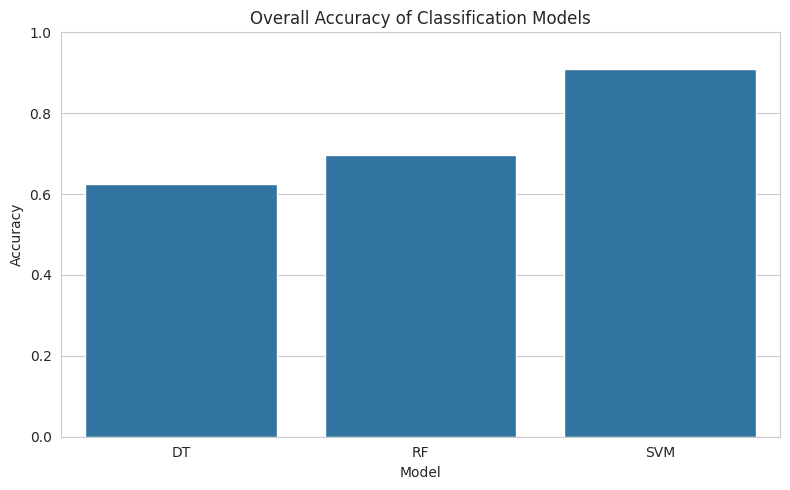

In [20]:
# ===============================
# 5. VISUAL COMPARISON OF METRICS
# ===============================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 5.1 Overall Accuracy Comparison
plt.figure(figsize=(8, 5))
sns.barplot(x=dfAcc.index, y="accuracy", data=dfAcc)
plt.title("Overall Accuracy of Classification Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

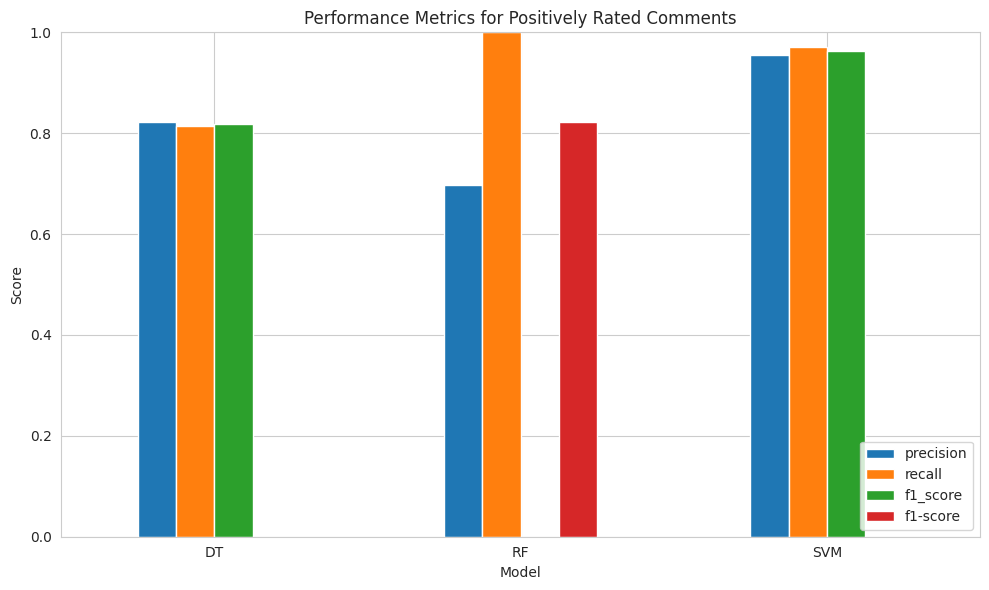

In [21]:
# 5.2 Performance Metrics for Positively Rated Comments
plt.figure(figsize=(10, 6))
modPerformancePos.plot(kind="bar", figsize=(10, 6), legend=True)
plt.title("Performance Metrics for Positively Rated Comments")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


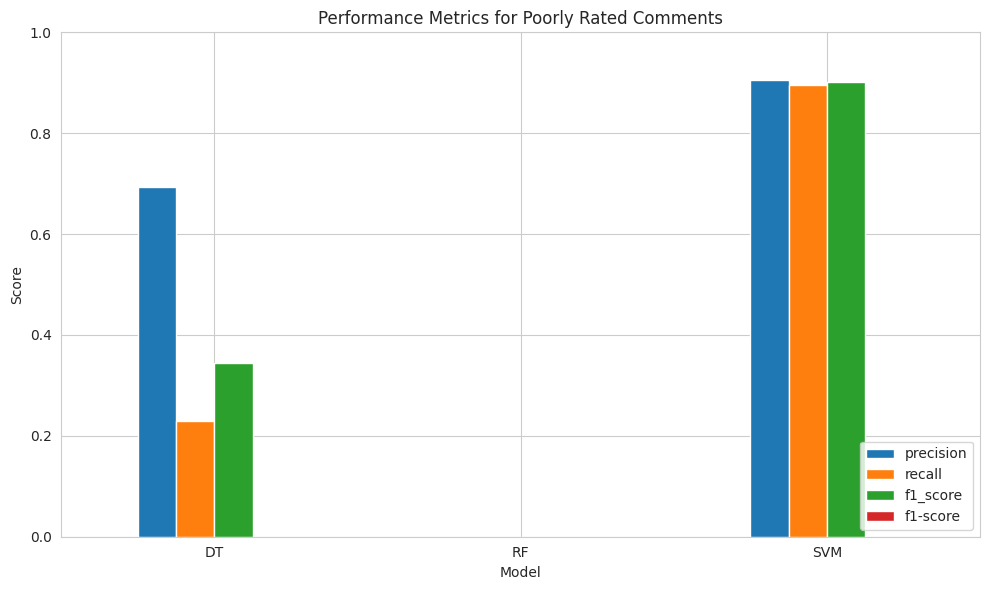

In [22]:
# 5.3 Performance Metrics for Poorly Rated Comments
ax = modPerformanceNeg.plot(kind="bar", figsize=(10, 6))
ax.set_title("Performance Metrics for Poorly Rated Comments")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


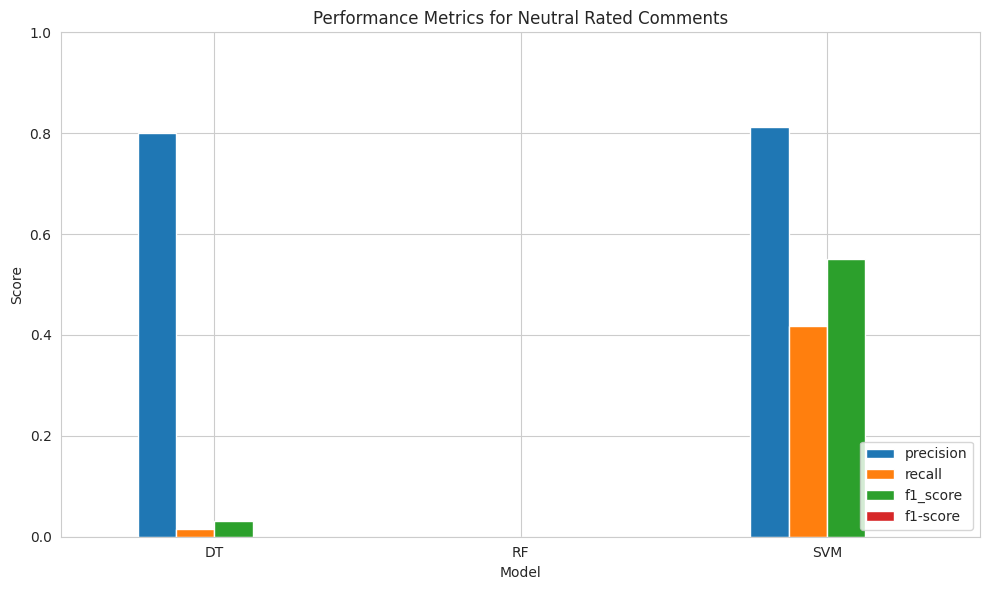

In [23]:
# 5.4 Performance Metrics for Neutral Rated Comments
ax = modPerformanceNeut.plot(kind="bar", figsize=(10, 6))
ax.set_title("Performance Metrics for Neutral Rated Comments")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


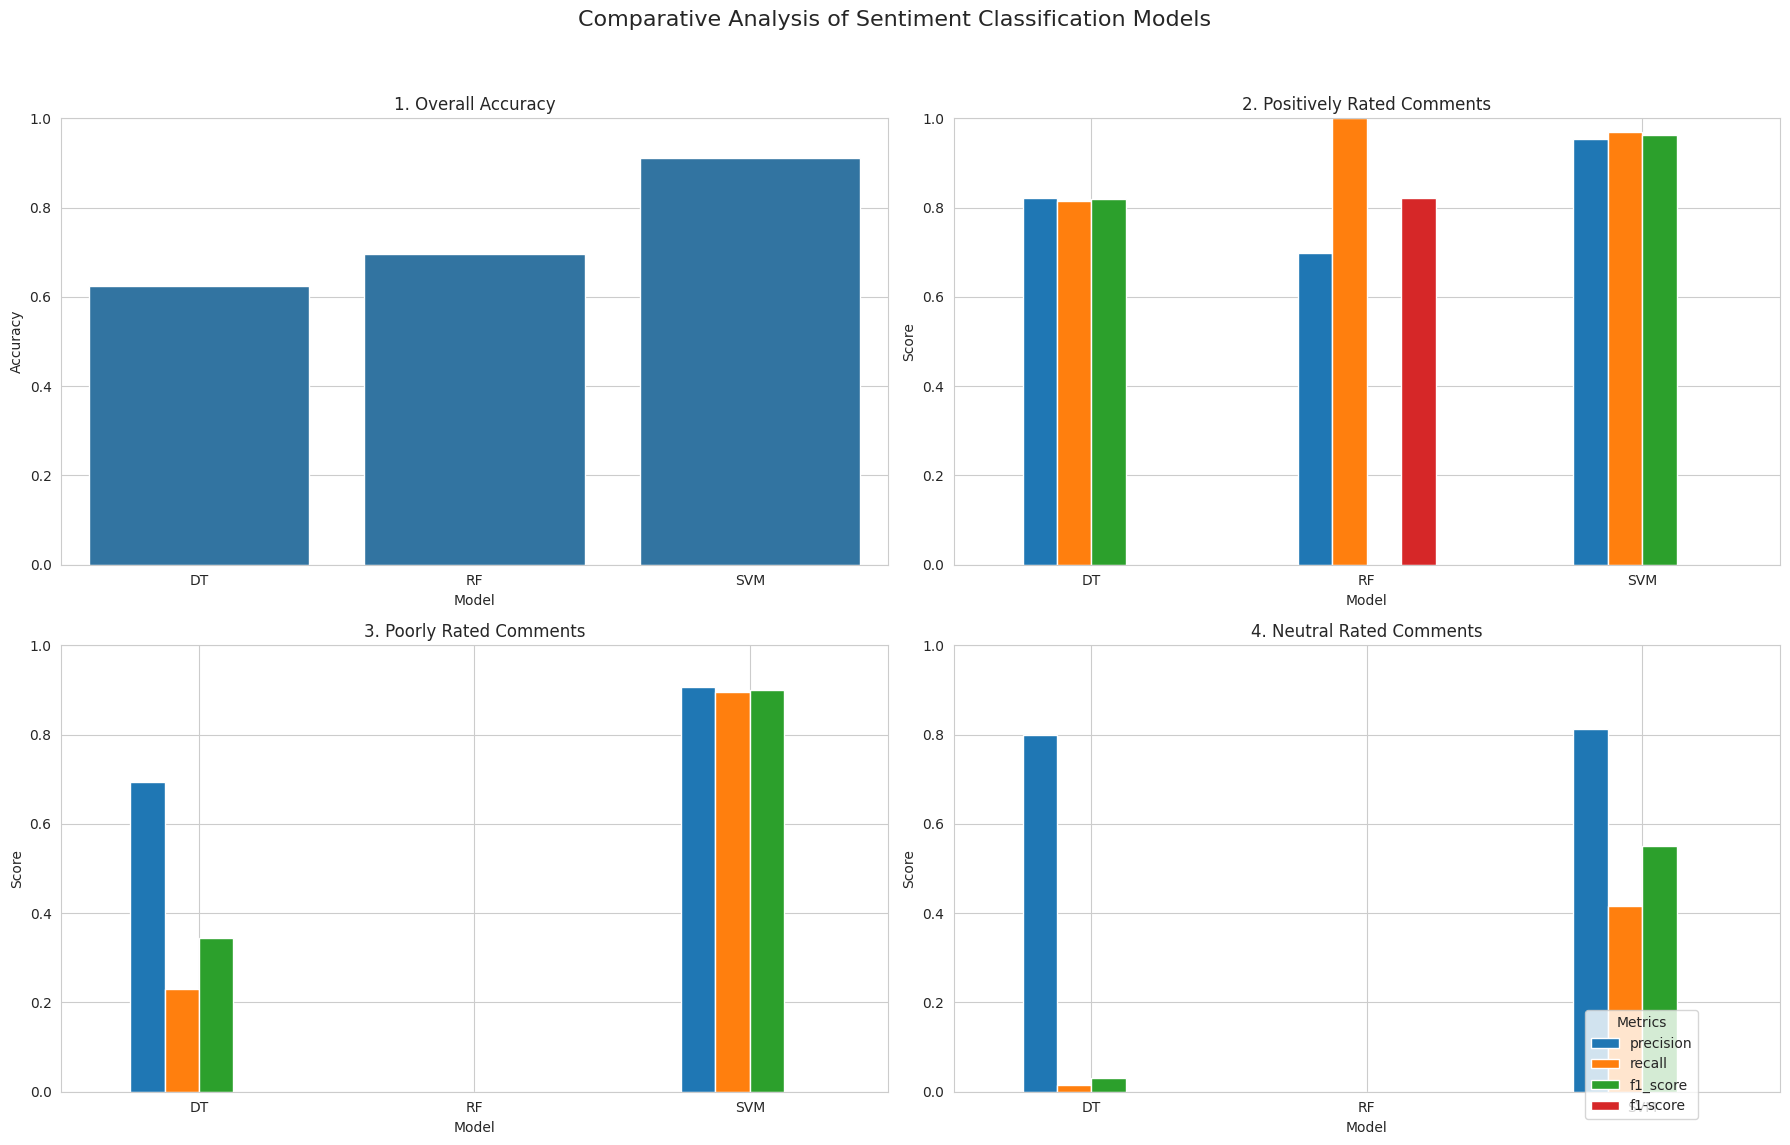

In [24]:
# ===============================
# 5.5 FINAL COMPARATIVE DASHBOARD
# ===============================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Comparative Analysis of Sentiment Classification Models", fontsize=16)

# 1. Overall Accuracy
sns.barplot(x=dfAcc.index, y="accuracy", data=dfAcc, ax=axes[0, 0])
axes[0, 0].set_title("1. Overall Accuracy")
axes[0, 0].set_xlabel("Model")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].set_ylim(0, 1)

# 2. Positively Rated Comments
modPerformancePos.plot(kind="bar", ax=axes[0, 1], legend=False)
axes[0, 1].set_title("2. Positively Rated Comments")
axes[0, 1].set_xlabel("Model")
axes[0, 1].set_ylabel("Score")
axes[0, 1].set_ylim(0, 1)
axes[0, 1].tick_params(axis="x", rotation=0)

# 3. Poorly Rated Comments
modPerformanceNeg.plot(kind="bar", ax=axes[1, 0], legend=False)
axes[1, 0].set_title("3. Poorly Rated Comments")
axes[1, 0].set_xlabel("Model")
axes[1, 0].set_ylabel("Score")
axes[1, 0].set_ylim(0, 1)
axes[1, 0].tick_params(axis="x", rotation=0)

# 4. Neutral Rated Comments
modPerformanceNeut.plot(kind="bar", ax=axes[1, 1], legend=False)
axes[1, 1].set_title("4. Neutral Rated Comments")
axes[1, 1].set_xlabel("Model")
axes[1, 1].set_ylabel("Score")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].tick_params(axis="x", rotation=0)

# Shared legend
handles, labels = axes[0, 1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", title="Metrics", bbox_to_anchor=(0.95, 0.05))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()